# Understanding Tourism Price Prediction Dataset
The dataset describes 6476 rows of up-to-date information on tourist expenditure collected by the National Bureau of Statistics (NBS) in Tanzania.The dataset was collected to gain a better understanding of the status of the tourism sector and provide an instrument that will enable sector growth.

Your goal is to accurately predict tourist expenditure when visiting Tanzania.

The majority of the visitors under the age group of 25-44 came for business (18.5%), or leisure and holidays (53.2%), which is consistent with the fact that they are economically more productive. Those at the age group of 45-64 were more prominent in holiday making and visiting friends and relatives. The results further reveal that most visitors belonging to the age group of 18-24 came for leisure and holidays (55.3%) as well as volunteering (13.7%). The majority of senior citizens (65 and above) came for leisure and holidays (80.9%) and visiting friends and relatives (9.5%).

The survey covers seven departure points, namely: Julius Nyerere International Airport, Kilimanjaro International Airport, Abeid Amani Karume International Airport, and the Namanga, Tunduma, Mtukula and Manyovu border points.

## Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import warnings 

%matplotlib inline
warnings.filterwarnings('ignore')

## Load Datasets

In [2]:
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
var_defn = pd.read_csv('VariableDefinitions.csv')
train = pd.read_csv('Train.csv')
submission = pd.read_csv('SampleSubmission.csv')

In [3]:
train.shape, test.shape

((4809, 23), (1601, 22))

## Understanding Data

In [4]:
# Columns in the dataset
train.columns

Index(['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'payment_mode', 'first_trip_tz', 'most_impressing',
       'total_cost'],
      dtype='object')

__Columns descriptions__

In [5]:
# Display variables and their definition

###########################################################
#           First way -> display(var_defn) or             #
###########################################################

# Set Pandas option for better display
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)
display(var_defn)

,Column Name,Definition
0,id,Unique identifier for each tourist
1,country,The country a tourist coming from.
2,age_group,The age group of a tourist.
3,travel_with,The relation of people a tourist travel with to Tanzania
4,total_female,Total number of females
5,total_male,Total number of males
6,purpose,The purpose of visiting Tanzania
7,main_activity,The main activity of tourism in Tanzania
8,infor_source,The source of information about tourism in Tanzania
9,tour_arrangment,The arrangment of visiting Tanzania


In [6]:
# Tourism dataset info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            3695 non-null   object 
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

Based on the dataset presented above, five columns are of the float64 data type, while eighteen columns are of the object data type. Furthermore, the variables ‘_travel_with_’, ‘_total_male_’, and ‘_most_impressing_’ contain missing values, as their non-null counts are lower than the total number of observations (4,809) recorded in the dataset.

In [7]:
# Descriptive Statistics on numerical columns
train.describe()

,total_female,total_male,night_mainland,night_zanzibar,total_cost
count,4806.000000,4804.000000,4809.000000,4809.000000,4.809000e+03
mean,0.926758,1.009575,8.488043,2.304429,8.114389e+06
std,1.288242,1.138865,10.427624,4.227080,1.222490e+07
min,0.000000,0.000000,0.000000,0.000000,4.900000e+04
25%,0.000000,1.000000,3.000000,0.000000,8.121750e+05
50%,1.000000,1.000000,6.000000,0.000000,3.397875e+06
75%,1.000000,1.000000,11.000000,4.000000,9.945000e+06
max,49.000000,44.000000,145.000000,61.000000,9.953288e+07


In [8]:
# Descriptive Statistics on all columns
train.describe(include='all')

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
count,4809,4809,4809,3695,4806.000000,4804.000000,4809,4809,4809,4809,...,4809,4809,4809,4809,4809.000000,4809.000000,4809,4809,4496,4.809000e+03
unique,4809,105,4,5,NaN,NaN,7,9,8,2,...,2,2,2,2,NaN,NaN,4,2,7,NaN
top,tour_0,UNITED STATES OF AMERICA,25-44,Alone,NaN,NaN,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,NaN,NaN,Cash,Yes,Friendly People,NaN
freq,1,695,2487,1265,NaN,NaN,2840,2259,1913,2570,...,2919,3319,3259,4079,NaN,NaN,4172,3243,1541,NaN
mean,NaN,NaN,NaN,NaN,0.926758,1.009575,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,8.488043,2.304429,NaN,NaN,NaN,8.114389e+06
std,NaN,NaN,NaN,NaN,1.288242,1.138865,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10.427624,4.227080,NaN,NaN,NaN,1.222490e+07
min,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,4.900000e+04
25%,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.000000,0.000000,NaN,NaN,NaN,8.121750e+05
50%,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.000000,0.000000,NaN,NaN,NaN,3.397875e+06
75%,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,11.000000,4.000000,NaN,NaN,NaN,9.945000e+06


From the above statistical summary, we can deduce some of the following insights:
 - The train data shows that the high travelling age group range *25 to 44* 
 - Most people travel Alone for leisure and holidays
 - Most travellers are from United states of America
 - The train data shows wildlife tourism is the main activity impying that most travellers spend more nights in mainland compared to zanzibar.

In [9]:
# Checking data structure of Tourism dataset (First 5 rows)
train.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [10]:
# Checking data structure of Tourism dataset (Last 5 rows)
train.tail()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
4804,tour_993,UAE,45-64,Alone,0.0,1.0,Business,Hunting tourism,"Friends, relatives",Independent,...,No,No,No,No,2.0,0.0,Credit Card,No,No comments,3315000.0
4805,tour_994,UNITED STATES OF AMERICA,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,Yes,11.0,0.0,Cash,Yes,Friendly People,10690875.0
4806,tour_995,NETHERLANDS,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,others,Independent,...,No,No,No,No,3.0,7.0,Cash,Yes,Good service,2246636.7
4807,tour_997,SOUTH AFRICA,25-44,Friends/Relatives,1.0,1.0,Business,Beach tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,5.0,0.0,Credit Card,No,Friendly People,1160250.0
4808,tour_999,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,4.0,7.0,Cash,Yes,Friendly People,13260000.0


## Data Cleaning

### Missing values

In [11]:
train.isnull().sum().any(), test.isnull().sum().any()

(True, True)

In [12]:
train[['travel_with', 'total_male', 'most_impressing']].isnull().sum()

travel_with        1114
total_male            5
most_impressing     313
dtype: int64

In [13]:
test[['travel_with', 'total_male', 'most_impressing']].isnull().sum()

travel_with        327
total_male           2
most_impressing    111
dtype: int64

The missing values identified above will be addressed during the model training process through the use of data preprocessing pipelines.

### Check for duplicate values

In [14]:
train.duplicated().any(), test.duplicated().any()

(False, False)

The dataset contains no duplicate records.

## EDA

In [15]:
# Correlation

top10_corr = abs(train.select_dtypes(include=['number']).corr()['total_cost']).sort_values(ascending = False).head(10)
top10_corr

total_cost        1.000000
total_female      0.286097
total_male        0.185848
night_zanzibar    0.145139
night_mainland    0.020473
Name: total_cost, dtype: float64

This illustrates the correlation among numerical variables. To examine the relationship between all variables and the target variable, categorical variables must first be transformed into numerical form (i.e., encoded from nominal categories into numeric values).

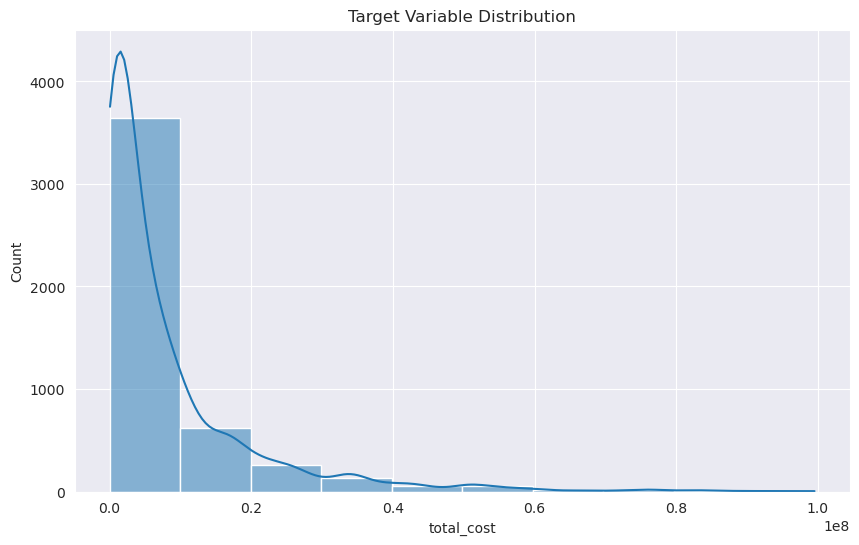

None

2.9678480498552684

In [16]:
# Target variable distribution
sns.set_style('darkgrid')
plt.figure(figsize = (10, 6))
sns.histplot(train.total_cost, kde=True, bins=10) # kde - Adds a smooth density curve on top of the histogram to show the probability distribution.
# (Seaborn only), bins -Sets the number of bins in the histogram
plt.title("Target Variable Distribution", fontsize=12)
display(plt.show(), train.total_cost.skew())

The target variable is skewed to the right (Positive skew) with a a degree of ~3.
- The right tail is longer, meaning more values are concentrated on the left.
- Most values are lower, but a few high values (outliers) pull the mean to the right.
- The mean > median > mode
- Because the variable is skewed to the right, it can be handled by <i>Log Transformation</i>

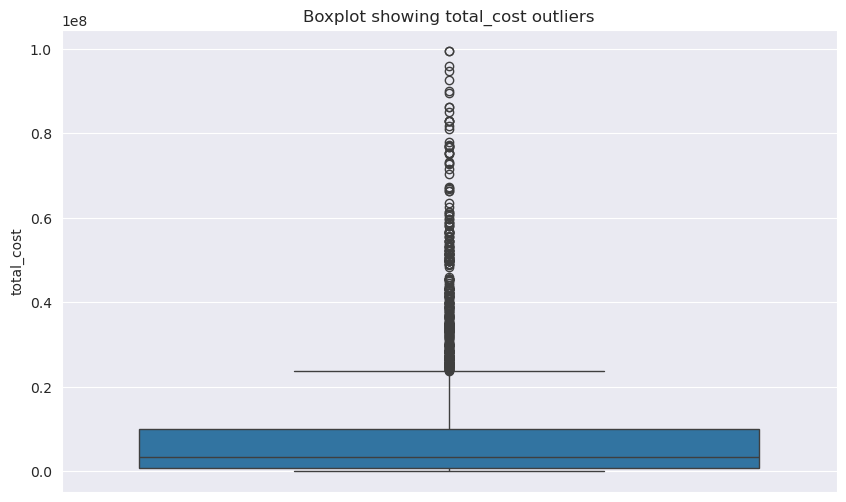

In [17]:
# Plotting boxplot for total_cost to check for outliers
sns.set_style('darkgrid')
plt.figure(figsize = (10, 6))
sns.boxplot(train.total_cost)
plt.title("Boxplot showing total_cost outliers", fontsize=12)
plt.show()

# Spliting Data

In [18]:
# Remove rows with missing target, separate target from predictors
y = train.total_cost
features = ['age_group', 'travel_with', 'total_female', 'total_male', 'purpose', 'main_activity', 'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'payment_mode', 'first_trip_tz', 'most_impressing']
X = train[features]

# Break off validation set from training data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
categorical_cols = [cname for cname in X_train.columns if X_train[cname].nunique() < 10 and 
                    X_train[cname].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in X_train.columns if X_train[cname].dtype in ['float64']]

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
train_X = X_train[my_cols].copy()
valid_X = X_valid[my_cols].copy()
X_test = test[my_cols].copy()

# Modeling

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='mean')

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # handling missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Define model
rf_model = RandomForestRegressor(n_estimators=100, random_state=1)

# Bundle preprocessing and modeling code in a pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

# Preprocessing of training data, fit model 
clf.fit(train_X, y_train)

# Preprocessing of validation data, get predictions
predictions = clf.predict(valid_X)

mae = mean_absolute_error(y_valid, predictions)
print("Mean Absolute Error: ", mae)

Mean Absolute Error:  5138636.041684616
